In [36]:
from Classes.Grid import Grid
from Classes.ScalarCoeffs import ScalarCoeffs
from Classes.BoundaryConditions import BoundaryLocation, DirichletBc, NeumannBc, RobinBc
from Classes.Models import DiffusionModel, SurfaceConvectionModel
from Classes.LinearSolver import solve

import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt

In [38]:
class FirstOrderTransientModel:
    """Class defining a first order implicit transient model"""

    def __init__(self, grid, T, Told, rho, cp, dt):
        """Constructor"""
        self._grid = grid
        self._T = T
        self._Told = Told
        self._rho = rho
        self._cp = cp
        self._dt = dt

    def add(self, coeffs):
        """Function to add transient term to coefficient arrays"""

        # Calculate the transient term
        rp_coeff = (self._rho * self._cp * self._grid.vol/ self._dt) * (self._T[1:-1] - self._Told[1:-1])

        # Calculate the linearization coefficient
        ap_coeff = (self._rho * self._cp * self._grid.vol/ dt)
        
        # Add to coefficient arrays
        coeffs.accumulate_aP(ap_coeff)
        coeffs.accumulate_rP(rp_coeff)
        
        return coeffs

In [40]:
class SecondOrderTransientModel:
    """Class defining a second order implicit transient model"""

    def __init__(self, grid, T, Told, Told2, rho, cp, dt):
        """Constructor"""
        self._grid = grid
        self._T = T
        self._Told = Told
        self._Told2 = Told2
        self._rho = rho
        self._cp = cp
        self._dt = dt

    def add(self, coeffs):
        """Function to add transient term to coefficient arrays"""
        
        # Calculate the transient term rhp * cp * V *(3T - 4Told + T^Told2) / (2 dt)
        rp_coeff = self._rho * self._cp * self._grid.vol * (3.0 * self._T[1:-1] - 4.0 * self._Told[1:-1] + self._Told2[1:-1]) / (2.0 * self._dt)

        # Calculate the linearization coefficient 3 rho cp V / (2 dt)
        ap_coeff = 3.0 * self._rho * self._cp * self._grid.vol / (2.0 * self._dt)
        
        # Add to coefficient arrays
        coeffs.accumulate_aP(ap_coeff)
        coeffs.accumulate_rP(rp_coeff)
        
        return coeffs

In [42]:
#define funciton for analytical solution
def analytical_T(x, tau):
    return To + (Ti - To) * C1 * np.exp(-zeta**2 * tau) * np.cos(zeta * x)

## Parameters define

In [45]:
#Parameters
Bi = 1
    
Ti = 100 #C
To = 0    #C
    
C1 = 1.1191
zeta = 0.8603
    
tau1 = 0.4535
tau2 = 3.2632
    
    
    
# Define the grid
lx = 1.0
ly = 0.1
lz = 0.1

# Set the timestep information
time = 0
 
# Set the maximum number of iterations and convergence criterion
maxIter = 10
converged = 1e-6
    
# Define thermophysical properties
rho = 1
cp = 1
k = 1
h = Bi * k / lx


## Define funciton for loop-running

In [48]:
#define function for running first order
def runcase_firstorder(grid, ntime):    
    
    # define local dt and grid
    dt = (tau2 - tau1) / ntime

    # Define the coefficients
    coeffs = ScalarCoeffs(grid.ncv)
    
    # Initial conditions
    #T0 = 300
    
    # Initialize field variable arrays
    T = analytical_T(grid.xP, tau1)
    
    # Define boundary conditions
    west_bc = NeumannBc(T, grid, 0.0, BoundaryLocation.WEST)
    east_bc = RobinBc(T, grid, h, k, To, BoundaryLocation.EAST)
    
    # Apply boundary conditions
    west_bc.apply()
    east_bc.apply()
    
    # Create list to store the solutions at each timestep
    # Note: If there are a lot of timesteps, this will cost a
    #       lot of memory. It is suggested to set a parameter to 
    #       only store the solution every N timesteps.
    T_solns = [np.copy(T)]
    
    # Define the transient model
    Told = np.copy(T)
    
    transient = FirstOrderTransientModel(grid, T, Told, rho, cp, dt)
    
    # Define the diffusion model
    diffusion = DiffusionModel(grid, T, k, west_bc, east_bc)
    
    time = tau1
    
    # Define the surface convection model (no need)
    #surfaceConvection = SurfaceConvectionModel(grid, T, ho, To)
    
    # Loop through all timesteps
    
    for tStep in range(ntime):
        # Update the time information
        time += dt
        
        # Print the timestep information
        print("First order: Timestep = {}; Time = {}".format(tStep, time))
        
        # Store the "old" temperature field
        # Note: do not use copy here because that creates a new object
        #       and we want the reference in the transient model to remain
        #       valid
        Told[:] = T[:]
        
        # Iterate until the solution is converged
        for i in range(maxIter):
            # Zero the coefficients and add each influence
            coeffs.zero()
            coeffs = diffusion.add(coeffs)
            #coeffs = surfaceConvection.add(coeffs)
            coeffs = transient.add(coeffs)
            
            # Compute residual and check for convergence 
            maxResid = norm(coeffs.rP, np.inf)
            avgResid = np.mean(np.absolute(coeffs.rP))
            print("First order: Iteration = {}; Max. Resid. = {}; Avg. Resid. = {}".format(i, maxResid, avgResid))
            
            if maxResid < converged:
                break
        
            # Solve the sparse matrix system
            dT = solve(coeffs)
        
            # Update the solution and boundary conditions
            T[1:-1] += dT
            west_bc.apply()
            east_bc.apply()
        
        # Store the solution
        T_solns.append(np.copy(T))

    return T, dt

In [50]:
#define function for running second order
def runcase_secondorder(grid, ntime):
    
    # define local dt and grid
    dt = (tau2 - tau1) / ntime
    
    # Define the coefficients
    coeffs = ScalarCoeffs(grid.ncv)
    
    # Initial conditions
    #T0 = 300
    
    # Initialize field variable arrays
    T = analytical_T(grid.xP, tau1)
    
    # Define boundary conditions
    west_bc = NeumannBc(T, grid, 0.0, BoundaryLocation.WEST)
    east_bc = RobinBc(T, grid, h, k, To, BoundaryLocation.EAST)
    
    # Apply boundary conditions
    west_bc.apply()
    east_bc.apply()
    
    # Create list to store the solutions at each timestep
    T_solns = [np.copy(T)]
    
    # Define the surface convection model
    #surfaceConvection = SurfaceConvectionModel(grid, T, ho, To)
    
    # Loop through all timesteps
    Told = np.copy(T)
    Told2 = np.copy(T)
    
    diffusion = DiffusionModel(grid, T, k, west_bc, east_bc)
    
    time = tau1
    
    for tStep in range(ntime):
    
        time += dt
    
        print("Second order: Timestep = {}; Time = {}".format(tStep + 1, time))
    
        if tStep == 0:
            # First timestep: use first-order implicit because T^{n-1} is unavailable
            Told[:] = T[:]
    
            transient = FirstOrderTransientModel(
                grid, T, Told, rho, cp, dt
            )
    
        else:
            # Second-order implicit:
            # Told  = T^n
            # Told2 = T^{n-1}
            Told2[:] = Told[:]
            Told[:] = T[:]
    
            transient = SecondOrderTransientModel(
                grid, T, Told, Told2, rho, cp, dt
            )
    
        for i in range(maxIter):
    
            coeffs.zero()
    
            coeffs = diffusion.add(coeffs)
            coeffs = transient.add(coeffs)
    
            maxResid = norm(coeffs.rP, np.inf)
            avgResid = np.mean(np.absolute(coeffs.rP))
    
            print("Second order: Iteration = {}; Max. Resid. = {}; Avg. Resid. = {}".format(
                i, maxResid, avgResid
            ))
    
            if maxResid < converged:
                break
    
            dT = solve(coeffs)
    
            T[1:-1] += dT
    
            west_bc.apply()
            east_bc.apply()
    
        T_solns.append(np.copy(T))

    return T, dt

In [52]:
#running as a loop for differet time steps
nTime_list = np.array([2, 4, 8, 16, 32])

ncv = 5
grid = Grid(lx, ly, lz, ncv)

#define array for error and T0

dt_values = []

error_first = []
error_second = []

T0_first = []
T0_second = []

T_exact_final = analytical_T(grid.xP, tau2)


for nTime in nTime_list:

    
    dt = (tau2 - tau1) / nTime
    
    print(f"Running nTime = {nTime}")
    print(f"Running dt = {dt}")
    
    T_first, dt = runcase_firstorder(grid, nTime)
    T_second, dt = runcase_secondorder(grid, nTime)
    
    
    dt_values.append(dt)

    # Average absolute error over interior CVs
    err_first = np.mean(np.abs(T_exact_final[1:-1] - T_first[1:-1]))
    err_second = np.mean(np.abs(T_exact_final[1:-1] - T_second[1:-1]))

    error_first.append(err_first)
    error_second.append(err_second)

    # T(0, t2)
    T0_first.append(T_first[0])
    T0_second.append(T_second[0])

dt_values = np.array(dt_values)

error_first = np.array(error_first)
error_second = np.array(error_second)

T0_first = np.array(T0_first)
T0_second = np.array(T0_second)


Running nTime = 2
Running dt = 1.40485
First order: Timestep = 0; Time = 1.85835
First order: Iteration = 0; Max. Resid. = 0.11769287381022552; Avg. Resid. = 0.10399272829619466
First order: Iteration = 1; Max. Resid. = 6.869504964868156e-16; Avg. Resid. = 2.6645352591003756e-16
First order: Timestep = 1; Time = 3.2632
First order: Iteration = 0; Max. Resid. = 0.05773258406088999; Avg. Resid. = 0.05111274271925761
First order: Iteration = 1; Max. Resid. = 2.42861286636753e-16; Avg. Resid. = 1.0824674490095276e-16
Second order: Timestep = 1; Time = 1.85835
Second order: Iteration = 0; Max. Resid. = 0.11769287381022552; Avg. Resid. = 0.10399272829619466
Second order: Iteration = 1; Max. Resid. = 6.869504964868156e-16; Avg. Resid. = 2.6645352591003756e-16
Second order: Timestep = 2; Time = 3.2632
Second order: Iteration = 0; Max. Resid. = 0.08659887609133506; Avg. Resid. = 0.07666911407888631
Second order: Iteration = 1; Max. Resid. = 3.0184188481996443e-16; Avg. Resid. = 1.02695629777826

## Independence test

In [70]:
#check mesh independent
print("5 ncv --> First order: T final at ntime = 2 --> {}".format(T0_first[1]))
print("5 ncv --> Second order: T final at ntime = 2 --> {}".format(T0_second[1]))


5 ncv --> First order: T final at ntime = 2 --> 14.992649566497018
5 ncv --> Second order: T final at ntime = 2 --> 10.783391684215099


In [72]:
#rerun for 10 ncv
#running as a loop for differet time steps
ncv = 10  # increase from 5 to 10
grid = Grid(lx, ly, lz, ncv)

#define array for error and T0

dt_values = []

error_first = []
error_second = []

T0_first = []
T0_second = []

T_exact_final = analytical_T(grid.xP, tau2)


for nTime in nTime_list:

    
    dt = (tau2 - tau1) / nTime
    
    print(f"Running nTime = {nTime}")
    print(f"Running dt = {dt}")
    
    T_first, dt = runcase_firstorder(grid, nTime)
    T_second, dt = runcase_secondorder(grid, nTime)
    
    
    dt_values.append(dt)

    # Average absolute error over interior CVs
    err_first = np.mean(np.abs(T_exact_final[1:-1] - T_first[1:-1]))
    err_second = np.mean(np.abs(T_exact_final[1:-1] - T_second[1:-1]))

    error_first.append(err_first)
    error_second.append(err_second)

    # T(0, t2)
    T0_first.append(T_first[0])
    T0_second.append(T_second[0])

dt_values = np.array(dt_values)

error_first = np.array(error_first)
error_second = np.array(error_second)

T0_first = np.array(T0_first)
T0_second = np.array(T0_second)


Running nTime = 2
Running dt = 1.40485
First order: Timestep = 0; Time = 1.85835
First order: Iteration = 0; Max. Resid. = 0.05911956219801624; Avg. Resid. = 0.05213114913902881
First order: Iteration = 1; Max. Resid. = 1.1379786002407855e-15; Avg. Resid. = 5.009881398621019e-16
First order: Timestep = 1; Time = 3.2632
First order: Iteration = 0; Max. Resid. = 0.028988545320331124; Avg. Resid. = 0.02557326210755944
First order: Iteration = 1; Max. Resid. = 6.609296443471635e-16; Avg. Resid. = 2.555247680113837e-16
Second order: Timestep = 1; Time = 1.85835
Second order: Iteration = 0; Max. Resid. = 0.05911956219801624; Avg. Resid. = 0.05213114913902881
Second order: Iteration = 1; Max. Resid. = 1.1379786002407855e-15; Avg. Resid. = 5.009881398621019e-16
Second order: Timestep = 2; Time = 3.2632
Second order: Iteration = 0; Max. Resid. = 0.04348281798049673; Avg. Resid. = 0.038359893161338934
Second order: Iteration = 1; Max. Resid. = 7.4593109467002705e-16; Avg. Resid. = 2.795506881536

In [74]:
#check mesh independent
print("10 ncv --> First order: T final at ntime = 2 --> {}".format(T0_first[1]))
print("10 ncv --> Second order: T final at ntime = 2 --> {}".format(T0_second[1]))


10 ncv --> First order: T final at ntime = 2 --> 14.99807367924997
10 ncv --> Second order: T final at ntime = 2 --> 10.79336980730315


In [76]:
#rerun for 20 ncv
#running as a loop for differet time steps
ncv = 20
grid = Grid(lx, ly, lz, ncv)

#define array for error and T0

dt_values = []

error_first = []
error_second = []

T0_first = []
T0_second = []

T_exact_final = analytical_T(grid.xP, tau2)


for nTime in nTime_list:

    
    dt = (tau2 - tau1) / nTime
    
    print(f"Running nTime = {nTime}")
    print(f"Running dt = {dt}")
    
    T_first, dt = runcase_firstorder(grid, nTime)
    T_second, dt = runcase_secondorder(grid, nTime)
    
    
    dt_values.append(dt)

    # Average absolute error over interior CVs
    err_first = np.mean(np.abs(T_exact_final[1:-1] - T_first[1:-1]))
    err_second = np.mean(np.abs(T_exact_final[1:-1] - T_second[1:-1]))

    error_first.append(err_first)
    error_second.append(err_second)

    # T(0, t2)
    T0_first.append(T_first[0])
    T0_second.append(T_second[0])

dt_values = np.array(dt_values)

error_first = np.array(error_first)
error_second = np.array(error_second)

T0_first = np.array(T0_first)
T0_second = np.array(T0_second)

Running nTime = 2
Running dt = 1.40485
First order: Timestep = 0; Time = 1.85835
First order: Iteration = 0; Max. Resid. = 0.029593993706063772; Avg. Resid. = 0.026083070032713308
First order: Iteration = 1; Max. Resid. = 3.875372245332187e-15; Avg. Resid. = 1.0330278299441886e-15
First order: Timestep = 1; Time = 3.2632
First order: Iteration = 0; Max. Resid. = 0.014509565669382595; Avg. Resid. = 0.012788745199506669
First order: Iteration = 1; Max. Resid. = 1.1666015375944028e-15; Avg. Resid. = 5.408867798095685e-16
Second order: Timestep = 1; Time = 1.85835
Second order: Iteration = 0; Max. Resid. = 0.029593993706063772; Avg. Resid. = 0.026083070032713308
Second order: Iteration = 1; Max. Resid. = 3.875372245332187e-15; Avg. Resid. = 1.0330278299441886e-15
Second order: Timestep = 2; Time = 3.2632
Second order: Iteration = 0; Max. Resid. = 0.0217643485040733; Avg. Resid. = 0.019183117799260317
Second order: Iteration = 1; Max. Resid. = 1.6263032587282567e-15; Avg. Resid. = 4.7655022

In [63]:
#check mesh independent
print("20 ncv --> First order: T final at ntime = 2 --> {}".format(T0_first[1]))
print("20 ncv --> Second order: T final at ntime = 2 --> {}".format(T0_second[1]))


20 ncv --> First order: T final at ntime = 2 --> 14.992649566497018
20 ncv --> Second order: T final at ntime = 2 --> 10.783391684215099


## Mesh Independence
A grid with 10 control volumes was selected because further mesh refinement produced less than a 5% change in the final temperature. Therefore, the solution was considered mesh independent for the present study.

In [ ]:
ncv = 10
grid = Grid(lx, ly, lz, ncv)

#define array for error and T0

dt_values = []

error_first = []
error_second = []

T0_first = []
T0_second = []

T_exact_final = analytical_T(grid.xP, tau2)


for nTime in nTime_list:

    
    dt = (tau2 - tau1) / nTime
    
    print(f"Running nTime = {nTime}")
    print(f"Running dt = {dt}")
    
    T_first, dt = runcase_firstorder(grid, nTime)
    T_second, dt = runcase_secondorder(grid, nTime)
    
    
    dt_values.append(dt)

    # Average absolute error over interior CVs
    err_first = np.mean(np.abs(T_exact_final[1:-1] - T_first[1:-1]))
    err_second = np.mean(np.abs(T_exact_final[1:-1] - T_second[1:-1]))

    error_first.append(err_first)
    error_second.append(err_second)

    # T(0, t2)
    T0_first.append(T_first[0])
    T0_second.append(T_second[0])

dt_values = np.array(dt_values)

error_first = np.array(error_first)
error_second = np.array(error_second)

T0_first = np.array(T0_first)
T0_second = np.array(T0_second)

First-order implicit p  = 0.9466
Second-order implicit p = 2.5045


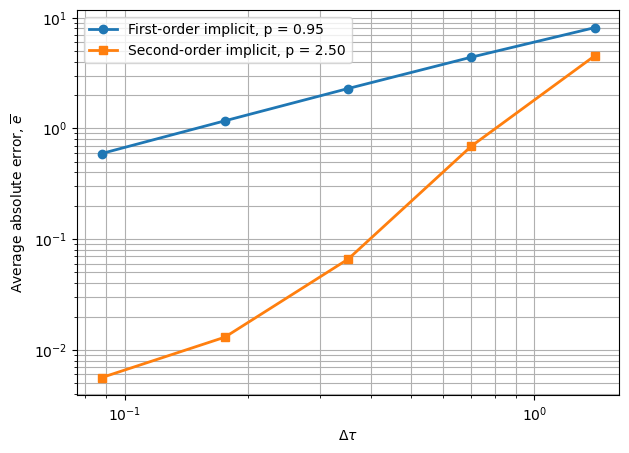

In [65]:
%matplotlib inline

p_first, logc_first = np.polyfit(np.log(dt_values), np.log(error_first), 1)
p_second, logc_second = np.polyfit(np.log(dt_values), np.log(error_second), 1)

print(f"First-order implicit p  = {p_first:.4f}")
print(f"Second-order implicit p = {p_second:.4f}")

plt.figure(figsize=(7, 5))

plt.loglog(
    dt_values,
    error_first,
    "o-",
    linewidth=2,
    label=f"First-order implicit, p = {p_first:.2f}"
)

plt.loglog(
    dt_values,
    error_second,
    "s-",
    linewidth=2,
    label=f"Second-order implicit, p = {p_second:.2f}"
)

plt.xlabel(r"$\Delta \tau$")
plt.ylabel(r"Average absolute error, $\overline{e}$")
plt.grid(True, which="both")
plt.legend()
plt.show()


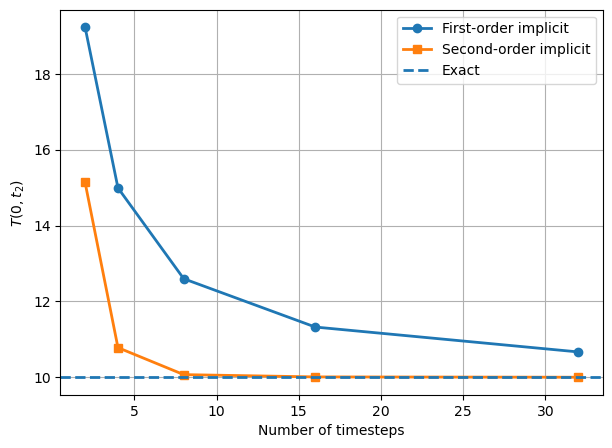

In [67]:
%matplotlib inline
plt.figure(figsize=(7, 5))

plt.plot(
    nTime_list,
    T0_first,
    "o-",
    linewidth=2,
    label="First-order implicit"
)

plt.plot(
    nTime_list,
    T0_second,
    "s-",
    linewidth=2,
    label="Second-order implicit"
)

plt.axhline(
    analytical_T(0.0, tau2),
    linestyle="--",
    linewidth=2,
    label="Exact"
)

plt.xlabel("Number of timesteps")
plt.ylabel(r"$T(0,t_2)$")
plt.grid(True)
plt.legend()
plt.show()